# OVRO-LWA source metacatalog

Identify sources in OVRO-LWA wide-field FITS images with **PyBDSF**, then fuse
per-image catalogs into a **metacatalog** with one entry per unique sky position.

Pipeline (library: `lwa_catalog.create` + Parquet I/O):

1. **Discover** FITS under `FITS_ROOT` (LST hour + color band from filenames).
2. **Detect** sources per image (`detect_sources`).
3. **LST merge** within each band (`merge_lst_metacatalog`).
4. **Band merge** sequential Full→Blue→Green→Red (`build_global_metacatalog`).

Catalogs are written as **Parquet** under `OUTPUT_DIR` via `CatalogLayout`.
Set `REUSE_CACHED_CATALOGS = True` to skip PyBDSF / LST merge when caches exist.
Set `MIGRATE_LEGACY_CSV = True` once to convert old CSV/FITS catalog trees.


In [1]:
from __future__ import annotations

from pathlib import Path

import pandas as pd

from lwa_catalog import CatalogLayout, migrate_output_dir
from lwa_catalog.create import (
    build_global_metacatalog,
    detect_sources,
    discover_fits_files,
    discovered_slots,
    lst_hours_from_discovery,
    merge_lst_metacatalog,
)
from lwa_catalog.io import (
    lst_merged_cache_complete,
    read_all_lst_merged,
    read_sources_catalog,
    sources_cache_complete,
    write_lst_merged,
    write_metacatalog,
    write_sources_catalog,
)

###
# Improvements
# 1. use robust-0.75 with pbcorr, then upsample inputs before bdsf
# 2. 
# 3. add subbands to cross match
###

# --- user configuration ---------------------------------------------------
#FITS_ROOT = Path("/fast/claw")  # directory containing FITS images (searched recursively)
FITS_ROOT = Path("/lustre/pipeline/exopipe/phase3/coadd/Run_MASTERS1_20241218-20250827")
# Glob(s) relative to FITS_ROOT (rglob). Default: all .fits. Examples:
#   "I_*_deep_Taper_R0_*.fits"  or  ("*.fits", "*_LST*h_*.fits")
#FITS_GLOB: str | tuple[str, ...] = "*.fits"
FITS_GLOB = "??h_[RGBF]*//*_I_deep_Taper_Robust+0.0_dewarped*fits" 
OUTPUT_DIR = Path("/fast/claw/metacatalog_coadd2")  # Parquet catalog tree

# PyBDSF detection parameters
BDSF_KW = dict(
    thresh="hard",
    thresh_isl=3.0,
    thresh_pix=3.0,
    atrous_do=False,
    psf_vary_do=False,
    quiet=True,
    ncores=16,
)

# Optional subset of LST hour bins (e.g. ["01h", "02h"]). None = all discovered.
LST_HOURS_OVERRIDE: list[str] | None = None
ASSOC_BANDS = ("Blue", "Green", "Red")

# When True, skip PyBDSF / LST merge if matching Parquet files already exist
REUSE_CACHED_CATALOGS = False

# One-time CSV/FITS → Parquet migration (no-op if only Parquet is present)
MIGRATE_LEGACY_CSV = False

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
layout = CatalogLayout(OUTPUT_DIR)

if MIGRATE_LEGACY_CSV:
    migrated = migrate_output_dir(layout)
    print(f"Migrated {len(migrated)} legacy catalog file(s) under {OUTPUT_DIR}")


## Filename parsing

Discover FITS under `FITS_ROOT` and parse LST hour / color band from filenames
(`lwa_catalog.create.discover`). Band names are defined as notebook constants below.


In [2]:
# Explicit catalog constants (notebook-local; passed into library APIs below)
COLOR_BANDS = ("Full", "Blue", "Green", "Red")


In [3]:
_fits_patterns = (FITS_GLOB,) if isinstance(FITS_GLOB, str) else tuple(FITS_GLOB)
fits_files = discover_fits_files(FITS_ROOT, patterns=_fits_patterns)
_discovered_lst_hours = lst_hours_from_discovery(fits_files)
LST_HOURS = list(LST_HOURS_OVERRIDE) if LST_HOURS_OVERRIDE is not None else _discovered_lst_hours
fits_by_slot = discovered_slots(fits_files)
summary = pd.DataFrame(
    {
        "path": [m.path.name for m in fits_files],
        "lst_hour": [m.lst_hour for m in fits_files],
        "band": [m.band for m in fits_files],
        "time_key": [m.time_key for m in fits_files],
    }
)
print(f"Found {len(fits_files)} FITS files under {FITS_ROOT} matching {list(_fits_patterns)}")
print(
    f"LST hours from discovery ({len(_discovered_lst_hours)}): "
    f"{', '.join(_discovered_lst_hours)}"
)
if LST_HOURS_OVERRIDE is not None:
    print(f"LST hours in use (override): {', '.join(LST_HOURS)}")
else:
    print(f"LST hours in use (all discovered): {', '.join(LST_HOURS)}")
summary.sort_values(["lst_hour", "band"]).reset_index(drop=True)


Found 93 FITS files under /lustre/pipeline/exopipe/phase3/coadd/Run_MASTERS1_20241218-20250827 matching ['??h_[RGBF]*//*_I_deep_Taper_Robust+0.0_dewarped*fits']
LST hours from discovery (24): 00h, 01h, 02h, 03h, 04h, 05h, 06h, 07h, 08h, 09h, 10h, 11h, 12h, 13h, 14h, 15h, 16h, 17h, 18h, 19h, 20h, 21h, 22h, 23h
LST hours in use (all discovered): 00h, 01h, 02h, 03h, 04h, 05h, 06h, 07h, 08h, 09h, 10h, 11h, 12h, 13h, 14h, 15h, 16h, 17h, 18h, 19h, 20h, 21h, 22h, 23h


,path,lst_hour,band,time_key
0,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,00h,Blue,None
1,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,00h,Full,None
2,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,00h,Green,None
3,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...,00h,Red,None
4,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,01h,Blue,None
...,...,...,...,...
88,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,22h,Blue,None
89,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,22h,Full,None
90,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,22h,Green,None
91,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...,22h,Red,None


## PyBDSF source detection

Detect sources per image with PyBDSF (`lwa_catalog.create.detect`).
`GAUL_COLUMNS` and `BDSF_KW` are notebook-local; cache helpers wrap Parquet I/O.


In [4]:
GAUL_COLUMNS = [
    "RA",
    "DEC",
    "E_RA",
    "E_DEC",
    "Total_flux",
    "E_Total_flux",
    "Peak_flux",
    "E_Peak_flux",
    "Maj",
    "E_Maj",
    "Min",
    "E_Min",
    "PA",
    "E_PA",
    "DC_Maj",
    "DC_Min",
    "DC_PA",
    "S_Code",
    "Gaus_id",
    "Isl_id",
    "Source_id",
    "Resid_Isl_rms",
    "Resid_Isl_mean",
]


def all_sources_cached() -> bool:
    """True when every discovered (lst, band) slot has a sources Parquet file."""
    return sources_cache_complete(layout, sorted(fits_by_slot))


def all_lst_merged_cached() -> bool:
    """True when every color band has an LST-merged Parquet file."""
    return lst_merged_cache_complete(layout, COLOR_BANDS)


def load_sources_catalog(lst_hour: str, band: str) -> pd.DataFrame:
    """Load a per-image sources Parquet catalog, backfilling beam from the FITS image."""
    meta = fits_by_slot[(lst_hour, band)]
    return read_sources_catalog(layout, lst_hour, band, fits_path=meta.path)


def load_per_image_catalogs_from_disk() -> dict[tuple[str, str], pd.DataFrame]:
    """Load all per-image catalogs from OUTPUT_DIR when every slot is cached."""
    catalogs: dict[tuple[str, str], pd.DataFrame] = {}
    for lst_hour, band in sorted(fits_by_slot):
        catalogs[(lst_hour, band)] = load_sources_catalog(lst_hour, band)
    return catalogs


def load_lst_merged_from_disk() -> dict[str, pd.DataFrame]:
    """Load LST-merged per-band catalogs from OUTPUT_DIR."""
    return read_all_lst_merged(layout, COLOR_BANDS)


In [5]:
per_image_catalogs: dict[tuple[str, str], pd.DataFrame] = {}

for (lst_hour, band), meta in sorted(fits_by_slot.items()):
    key = (lst_hour, band)
    out_path = layout.sources(lst_hour, band)

    if REUSE_CACHED_CATALOGS and out_path.is_file():
        catalog = load_sources_catalog(lst_hour, band)
        per_image_catalogs[key] = catalog
        print(f"Cached {key}: {len(catalog)} sources <- {out_path.name}")
        continue

    catalog = detect_sources(meta, bdsf_kw=BDSF_KW, gaul_columns=GAUL_COLUMNS)
    per_image_catalogs[key] = catalog
    write_sources_catalog(catalog, layout, lst_hour, band)
    print(f"Detected {key}: {len(catalog)} sources -> {out_path.name}")


stty: 'standard input': Inappropriate ioctl for device
stty: 'standard input': Inappropriate ioctl for device
/opt/devel/claw/envs/py312/lib/python3.12/site-packages/bdsf/functions.py:624: RuntimeWarning: Number of calls to function has reached maxfev = 1400.
  p, success = leastsq(errorfunction, p_ini)


--> Wrote FITS file '/tmp/tmpvhlmo1t_.gaul.fits'
Detected ('00h', 'Blue'): 16976 sources -> sources_00h_Blue.parquet


stty: 'standard input': Inappropriate ioctl for device
stty: 'standard input': Inappropriate ioctl for device
/opt/devel/claw/envs/py312/lib/python3.12/site-packages/bdsf/functions.py:624: RuntimeWarning: Number of calls to function has reached maxfev = 1400.
  p, success = leastsq(errorfunction, p_ini)


--> Wrote FITS file '/tmp/tmpc5yewg14.gaul.fits'
Detected ('00h', 'Full'): 10151 sources -> sources_00h_Full.parquet


stty: 'standard input': Inappropriate ioctl for device
stty: 'standard input': Inappropriate ioctl for device


...

--> Wrote FITS file '/tmp/tmp5wgy4_hp.gaul.fits'
Detected ('22h', 'Green'): 7633 sources -> sources_22h_Green.parquet


stty: 'standard input': Inappropriate ioctl for device
stty: 'standard input': Inappropriate ioctl for device
/opt/devel/claw/envs/py312/lib/python3.12/site-packages/bdsf/functions.py:624: RuntimeWarning: Number of calls to function has reached maxfev = 1400.
  p, success = leastsq(errorfunction, p_ini)


--> Wrote FITS file '/tmp/tmp56kxs4tt.gaul.fits'
Detected ('22h', 'Red'): 3068 sources -> sources_22h_Red.parquet


stty: 'standard input': Inappropriate ioctl for device
stty: 'standard input': Inappropriate ioctl for device


--> Wrote FITS file '/tmp/tmpizl2qo9t.gaul.fits'
Detected ('23h', 'Red'): 3505 sources -> sources_23h_Red.parquet


## Metacatalog fusion

LST merge within each band, then sequential Full→Blue→Green→Red association
(`lwa_catalog.create.merge`). Band field lists and spectral-index inputs come from
`lwa_catalog.constants` (`BAND_FIELDS` includes `E_Total_flux` for `E_alpha_*`).


In [6]:
from lwa_catalog.constants import BAND_FIELDS

# BAND_FIELDS must include E_Total_flux so associated errors propagate into
# E_Total_flux_{band} and then E_alpha_RG / E_alpha_GB.
assert "E_Total_flux" in BAND_FIELDS


In [7]:
lst_merged: dict[str, pd.DataFrame] = {}

if REUSE_CACHED_CATALOGS and all_lst_merged_cached():
    lst_merged = load_lst_merged_from_disk()
    for band in COLOR_BANDS:
        print(
            f"LST merge ({band}): loaded {len(lst_merged[band])} sources from "
            f"{layout.lst_merged(band).name}"
        )
else:
    if not per_image_catalogs and REUSE_CACHED_CATALOGS and all_sources_cached():
        per_image_catalogs.update(load_per_image_catalogs_from_disk())
        print(f"Loaded {len(per_image_catalogs)} per-image catalogs from {OUTPUT_DIR}")

    for band in COLOR_BANDS:
        band_catalogs = [
            per_image_catalogs[(lst, band)]
            for lst in LST_HOURS
            if (lst, band) in per_image_catalogs
        ]
        merged = merge_lst_metacatalog(band_catalogs, band=band)
        lst_merged[band] = merged
        out_path = write_lst_merged(merged, layout, band)
        print(f"LST merge ({band}): {len(merged)} sources -> {out_path}")

metacatalog = build_global_metacatalog(
    lst_merged,
    assoc_bands=ASSOC_BANDS,
    band_fields=BAND_FIELDS,
    color_bands=COLOR_BANDS,
)
meta_path = write_metacatalog(metacatalog, layout)

if per_image_catalogs:
    n_inputs = sum(len(df) for df in per_image_catalogs.values())
    input_desc = f"{n_inputs} per-image detections"
else:
    n_inputs = sum(int(df["n_lst_contributions"].sum()) for df in lst_merged.values())
    input_desc = f"{n_inputs} LST-merged rows (cached)"
print(f"\nGlobal metacatalog: {len(metacatalog)} sources from {input_desc}")
print(f"Wrote {meta_path}")
metacatalog.head(10)


LST merge (Full): 27777 sources -> /fast/claw/metacatalog_coadd2/metacatalog_lst_Full.parquet
LST merge (Blue): 52174 sources -> /fast/claw/metacatalog_coadd2/metacatalog_lst_Blue.parquet
LST merge (Green): 29280 sources -> /fast/claw/metacatalog_coadd2/metacatalog_lst_Green.parquet
LST merge (Red): 12583 sources -> /fast/claw/metacatalog_coadd2/metacatalog_lst_Red.parquet

Global metacatalog: 51407 sources from 814856 per-image detections
Wrote /fast/claw/metacatalog_coadd2/metacatalog.parquet


,meta_id,origin_band,bands_present,RA,DEC,Peak_flux,Total_flux,Maj,Min,PA,...,n_assoc_Red,BMAJ_full,source_file_Full,source_file_Blue,source_file_Green,source_file_Red,alpha_RG,E_alpha_RG,alpha_GB,E_alpha_GB
0,0,Full,"Full,Red",252.779253,4.982932,271.315246,197.134127,0.199328,0.162670,40.385951,...,1,0.230495,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,NaN,NaN,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...,NaN,NaN,NaN,NaN
1,50803,Green,"Green,Red",76.171915,38.101275,246.795584,254.274878,0.227952,0.169666,39.711654,...,1,NaN,NaN,NaN,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...,-0.903261,0.012825,NaN,NaN
2,1,Full,"Full,Red",69.273245,29.624603,149.196896,199.827285,0.262656,0.182580,51.612433,...,1,0.217415,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,NaN,NaN,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...,NaN,NaN,NaN,NaN
3,2,Full,"Full,Blue,Green,Red",260.127202,-0.996968,138.173170,121.849322,0.229379,0.184686,51.914516,...,1,0.230495,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...,-6.357542,0.120543,-3.505343,0.166463
4,27777,Blue,"Blue,Red",49.939246,41.502988,120.813431,135.007862,0.175248,0.121493,43.898105,...,1,NaN,NaN,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,NaN,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...,NaN,NaN,NaN,NaN
5,3,Full,"Full,Green,Red",212.836288,52.201838,100.936015,91.707457,0.213419,0.159412,32.492999,...,1,0.226635,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,NaN,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...,0.009148,0.048708,NaN,NaN
6,4,Full,"Full,Blue,Green,Red",283.910531,1.411614,98.783553,226.089130,0.428834,0.255350,21.232580,...,1,0.234924,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...,-0.326497,0.036311,0.712901,0.024120
7,5,Full,"Full,Blue,Green,Red",64.596894,38.033690,98.577392,72.944456,0.195870,0.142178,44.959808,...,1,0.226294,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...,-1.569681,0.019646,-0.764583,0.014935
8,6,Full,"Full,Blue,Green,Red",277.396760,48.758092,82.409574,57.851491,0.193504,0.138026,43.759140,...,1,0.233604,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...,-0.929395,0.029974,-1.456359,0.019535
9,7,Full,"Full,Blue,Green,Red",303.611347,23.583143,81.328564,50.622625,0.186196,0.133859,36.980075,...,1,0.235147,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...,-0.522176,0.024188,-9.390960,0.228141


In [8]:
# LST merge yield (Full band)
full_lst = lst_merged["Full"]
multi_lst = full_lst[full_lst["n_lst_contributions"] > 1].sort_values("n_lst_contributions", ascending=False)
print(f"Full-band sources after LST merge: {len(full_lst)}")
print(f"  seen in multiple LST hours: {len(multi_lst)}")
if len(multi_lst):
    display(multi_lst.head(10)[["RA", "DEC", "Peak_flux", "n_lst_contributions", "lst_hours", "representative_lst"]])

# Global band merge
print(f"\nGlobal rows by origin_band:")
print(metacatalog["origin_band"].value_counts())

full_with_color = metacatalog[
    (metacatalog["origin_band"] == "Full")
    & (metacatalog[[f"n_assoc_{b}" for b in ASSOC_BANDS]].max(axis=1) > 0)
]
print(f"Full-seeded rows with at least one color-band association: {len(full_with_color)}")
metacatalog.head(10)[["meta_id", "RA", "DEC", "origin_band", "Peak_flux", "lst_hours", "n_assoc_Blue", "n_assoc_Green", "n_assoc_Red"]]

Full-band sources after LST merge: 27777
  seen in multiple LST hours: 24555


,RA,DEC,Peak_flux,n_lst_contributions,lst_hours,representative_lst
180,351.069014,58.755825,19.549941,190,"00h,01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,11...",00h
0,252.779253,4.982932,271.315246,150,"11h,12h,13h,14h,15h,16h,17h,18h,19h,20h,21h,22h",17h
1,69.273245,29.624603,149.196896,131,"00h,01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,11...",05h
472,300.570266,41.539691,13.467524,131,"00h,01h,02h,03h,04h,13h,14h,15h,16h,17h,18h,19...",20h
482,49.638599,41.867068,13.365159,128,"00h,01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,11...",03h
2742,83.674931,21.954735,6.236956,126,"00h,01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,11...",06h
9650,6.541411,63.932859,3.076213,123,"00h,01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,11...",00h
44,304.844997,40.179283,34.358293,114,"00h,01h,02h,03h,04h,13h,14h,15h,16h,17h,18h,19...",20h
25214,140.087575,-11.588076,1.474629,107,"04h,05h,06h,07h,08h,09h,10h,11h,12h,13h",09h
1014,187.865286,12.382799,9.957212,95,"06h,07h,08h,09h,10h,11h,12h,13h,14h,15h,16h,17...",13h



Global rows by origin_band:
origin_band
Full     27777
Blue     23026
Green      492
Red        112
Name: count, dtype: int64
Full-seeded rows with at least one color-band association: 27326


,meta_id,RA,DEC,origin_band,Peak_flux,lst_hours,n_assoc_Blue,n_assoc_Green,n_assoc_Red
0,0,252.779253,4.982932,Full,271.315246,"11h,12h,13h,14h,15h,16h,17h,18h,19h,20h,21h,22h",0,0,1
1,50803,76.171915,38.101275,Green,246.795584,"00h,01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,11...",0,1,1
2,1,69.273245,29.624603,Full,149.196896,"00h,01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,11...",0,0,1
3,2,260.127202,-0.996968,Full,138.173170,"12h,13h,14h,15h,16h,17h,18h,19h,20h,21h,22h",1,1,1
4,27777,49.939246,41.502988,Blue,120.813431,"00h,01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,11...",1,0,1
5,3,212.836288,52.201838,Full,100.936015,"05h,06h,07h,08h,09h,10h,11h,12h,13h,14h,15h,16...",0,1,1
6,4,283.910531,1.411614,Full,98.783553,"00h,14h,15h,16h,17h,18h,19h,20h,21h,22h",1,1,1
7,5,64.596894,38.033690,Full,98.577392,"00h,01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,11...",1,1,1
8,6,277.396760,48.758092,Full,82.409574,"00h,01h,02h,03h,10h,11h,12h,13h,14h,15h,16h,17...",1,1,1
9,7,303.611347,23.583143,Full,81.328564,"00h,01h,02h,14h,15h,16h,17h,18h,19h,20h,21h,22h",1,1,1


## Fit quality

Summarize detection fit quality on **`lst_merged`** (representative-row residuals and fluxes).
Requires the fusion cells above so `lst_merged` is populated.

Three categories:

1. **Island residual stats** — flag the top 1% of `Resid_Isl_rms` and the top 1% of
   `|Resid_Isl_mean|` within each band (union = high-residual set).
2. **Unphysical flux ratio** — allow `Total_flux < Peak_flux` within error; flag only when
   `(Total_flux - Peak_flux) / hypot(E_Total_flux, E_Peak_flux) < -3`.
   Rows missing either error are not flagged.
3. **Source density** — 1°×1° RA–Dec histogram; report densest bins and overlay flagged
   sources on a Full-band map. Flat RA–Dec bins exaggerate area near the NCP.

This section is read-only QA (does not rewrite Parquet catalogs).


In [9]:
import numpy as np

FLUX_UNPHYSICAL_NSIGMA = 3.0
RESIDUAL_PERCENTILE = 99.0  # top 1%
DENSITY_BIN_DEG = 3.0
FIT_QA_DISPLAY_ROWS = 15

_RESID_COLS = ("Resid_Isl_rms", "Resid_Isl_mean")
_FLUX_COLS = ("Total_flux", "Peak_flux", "E_Total_flux", "E_Peak_flux")
_POS_COLS = ("RA", "DEC")


def _missing_columns(df: pd.DataFrame, cols: tuple[str, ...]) -> list[str]:
    return [c for c in cols if c not in df.columns]


def flux_sigma_total_minus_peak(df: pd.DataFrame) -> pd.Series:
    """Return (Total - Peak) / hypot(E_Total, E_Peak); non-finite where inputs invalid."""
    missing = _missing_columns(df, _FLUX_COLS)
    if missing:
        return pd.Series(np.nan, index=df.index, dtype=float)
    total = df["Total_flux"].to_numpy(dtype=float)
    peak = df["Peak_flux"].to_numpy(dtype=float)
    e_tot = df["E_Total_flux"].to_numpy(dtype=float)
    e_peak = df["E_Peak_flux"].to_numpy(dtype=float)
    denom = np.hypot(e_tot, e_peak)
    sigma = np.full(len(df), np.nan, dtype=float)
    ok = (
        np.isfinite(total)
        & np.isfinite(peak)
        & np.isfinite(e_tot)
        & np.isfinite(e_peak)
        & (denom > 0)
    )
    sigma[ok] = (total[ok] - peak[ok]) / denom[ok]
    return pd.Series(sigma, index=df.index, name="flux_sigma_T_minus_P")


def flag_unphysical_flux(
    df: pd.DataFrame, *, nsigma: float = FLUX_UNPHYSICAL_NSIGMA
) -> pd.Series:
    """True where Total is significantly below Peak (sigma < -nsigma). Missing errors → False."""
    sigma = flux_sigma_total_minus_peak(df)
    return (sigma < -float(nsigma)).fillna(False).rename("unphysical_flux")


def flag_residual_top_percentile(
    df: pd.DataFrame, *, percentile: float = RESIDUAL_PERCENTILE
) -> pd.DataFrame:
    """Boolean columns: high_resid_rms, high_resid_abs_mean, high_residual (union)."""
    out = pd.DataFrame(index=df.index)
    missing = _missing_columns(df, _RESID_COLS)
    if missing:
        out["high_resid_rms"] = False
        out["high_resid_abs_mean"] = False
        out["high_residual"] = False
        return out

    rms = df["Resid_Isl_rms"].to_numpy(dtype=float)
    mean = df["Resid_Isl_mean"].to_numpy(dtype=float)
    abs_mean = np.abs(mean)

    high_rms = np.zeros(len(df), dtype=bool)
    high_abs = np.zeros(len(df), dtype=bool)

    finite_rms = np.isfinite(rms)
    if finite_rms.any():
        thr_rms = np.nanpercentile(rms[finite_rms], percentile)
        high_rms = finite_rms & (rms >= thr_rms)

    finite_abs = np.isfinite(abs_mean)
    if finite_abs.any():
        thr_abs = np.nanpercentile(abs_mean[finite_abs], percentile)
        high_abs = finite_abs & (abs_mean >= thr_abs)

    out["high_resid_rms"] = high_rms
    out["high_resid_abs_mean"] = high_abs
    out["high_residual"] = high_rms | high_abs
    return out


def sky_density_histogram(
    df: pd.DataFrame, *, bin_deg: float = DENSITY_BIN_DEG
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Return (H, ra_edges, dec_edges) for finite RA/DEC with fixed bin width in degrees."""
    missing = _missing_columns(df, _POS_COLS)
    if missing:
        return np.zeros((0, 0)), np.array([]), np.array([])
    ra = df["RA"].to_numpy(dtype=float)
    dec = df["DEC"].to_numpy(dtype=float)
    ok = np.isfinite(ra) & np.isfinite(dec)
    if not ok.any():
        return np.zeros((0, 0)), np.array([]), np.array([])
    ra = ra[ok]
    dec = dec[ok]
    bin_deg = float(bin_deg)
    ra_min, ra_max = np.floor(ra.min() / bin_deg) * bin_deg, np.ceil(ra.max() / bin_deg) * bin_deg
    dec_min, dec_max = np.floor(dec.min() / bin_deg) * bin_deg, np.ceil(dec.max() / bin_deg) * bin_deg
    if ra_max <= ra_min:
        ra_max = ra_min + bin_deg
    if dec_max <= dec_min:
        dec_max = dec_min + bin_deg
    n_ra = max(1, int(np.round((ra_max - ra_min) / bin_deg)))
    n_dec = max(1, int(np.round((dec_max - dec_min) / bin_deg)))
    ra_edges = ra_min + np.arange(n_ra + 1) * bin_deg
    dec_edges = dec_min + np.arange(n_dec + 1) * bin_deg
    H, _, _ = np.histogram2d(ra, dec, bins=[ra_edges, dec_edges])
    return H, ra_edges, dec_edges


def densest_bins(
    H: np.ndarray,
    ra_edges: np.ndarray,
    dec_edges: np.ndarray,
    *,
    n: int = 10,
) -> pd.DataFrame:
    """Return the densest histogram bins (count, bin centers)."""
    if H.size == 0:
        return pd.DataFrame(columns=["count", "RA_center", "DEC_center", "i_ra", "i_dec"])
    flat = H.ravel()
    order = np.argsort(flat)[::-1]
    rows = []
    for idx in order[: max(0, int(n))]:
        if flat[idx] <= 0:
            break
        i_ra, i_dec = np.unravel_index(int(idx), H.shape)
        rows.append(
            {
                "count": int(flat[idx]),
                "RA_center": float(0.5 * (ra_edges[i_ra] + ra_edges[i_ra + 1])),
                "DEC_center": float(0.5 * (dec_edges[i_dec] + dec_edges[i_dec + 1])),
                "i_ra": int(i_ra),
                "i_dec": int(i_dec),
            }
        )
    return pd.DataFrame(rows)


print(
    f"Fit-quality helpers ready "
    f"(residual p{RESIDUAL_PERCENTILE:g}, unphysical {FLUX_UNPHYSICAL_NSIGMA:g}σ, "
    f"density {DENSITY_BIN_DEG:g}°)."
)


Fit-quality helpers ready (residual p99, unphysical 3σ, density 3°).


In [10]:
# Per-band residual + unphysical flux summaries (stores fit_qa for density overlay)
fit_qa: dict[str, dict] = {}

for band in COLOR_BANDS:
    df = lst_merged[band]
    print(f"\n=== {band}: {len(df)} LST-merged sources ===")
    entry: dict = {
        "n_sources": int(len(df)),
        "high_residual": pd.Series(False, index=df.index),
        "unphysical_flux": pd.Series(False, index=df.index),
        "flux_sigma": pd.Series(np.nan, index=df.index),
        "skipped_residual": False,
        "skipped_flux": False,
    }

    miss_resid = _missing_columns(df, _RESID_COLS)
    if miss_resid:
        print(f"  SKIP residual QA — missing columns: {miss_resid}")
        entry["skipped_residual"] = True
        entry["n_resid_top1"] = 0
    else:
        flags = flag_residual_top_percentile(df, percentile=RESIDUAL_PERCENTILE)
        entry["high_residual"] = flags["high_residual"]
        entry["n_resid_top1"] = int(flags["high_residual"].sum())
        n_rms = int(flags["high_resid_rms"].sum())
        n_abs = int(flags["high_resid_abs_mean"].sum())
        n_finite_rms = int(np.isfinite(df["Resid_Isl_rms"].to_numpy(dtype=float)).sum())
        print(
            f"  Residual top-1%: union={entry['n_resid_top1']} "
            f"(rms={n_rms}, |mean|={n_abs}; finite Resid_Isl_rms={n_finite_rms})"
        )
        show_cols = [c for c in ["RA", "DEC", "Peak_flux", "Resid_Isl_rms", "Resid_Isl_mean", "S_Code"] if c in df.columns]
        outliers = (
            df.loc[flags["high_residual"], show_cols]
            .assign(_sort=df.loc[flags["high_residual"], "Resid_Isl_rms"])
            .sort_values("_sort", ascending=False)
            .drop(columns="_sort")
            .head(FIT_QA_DISPLAY_ROWS)
        )
        if len(outliers):
            display(outliers)
        else:
            print("  (no residual outliers)")

    miss_flux = _missing_columns(df, _FLUX_COLS)
    if miss_flux:
        print(f"  SKIP unphysical-flux QA — missing columns: {miss_flux}")
        entry["skipped_flux"] = True
        entry["n_unphysical_3sig"] = 0
    else:
        sigma = flux_sigma_total_minus_peak(df)
        unphys = flag_unphysical_flux(df, nsigma=FLUX_UNPHYSICAL_NSIGMA)
        entry["flux_sigma"] = sigma
        entry["unphysical_flux"] = unphys
        entry["n_unphysical_3sig"] = int(unphys.sum())
        print(f"  Unphysical flux (σ < -{FLUX_UNPHYSICAL_NSIGMA:g}): {entry['n_unphysical_3sig']}")
        show_cols = [c for c in ["RA", "DEC", "Total_flux", "Peak_flux", "E_Total_flux", "E_Peak_flux"] if c in df.columns]
        bad = df.loc[unphys, show_cols].copy()
        bad.insert(0, "flux_sigma_T_minus_P", sigma.loc[unphys])
        bad = bad.sort_values("flux_sigma_T_minus_P").head(FIT_QA_DISPLAY_ROWS)
        if len(bad):
            display(bad)
        else:
            print("  (no unphysical-flux sources)")

    fit_qa[band] = entry

print("\nStored per-band flags in fit_qa.")



=== Full: 27777 LST-merged sources ===
  Residual top-1%: union=412 (rms=283, |mean|=280; finite Resid_Isl_rms=27777)


,RA,DEC,Peak_flux,Resid_Isl_rms,Resid_Isl_mean,S_Code
8097,186.921031,12.071404,3.422931,15.989655,-9.954160,b'C'
12190,188.446087,12.819237,2.654049,15.989655,-9.954160,b'M'
1823,284.074191,2.115633,7.644357,2.859519,4.021516,b'M'
1817,286.772585,6.541013,7.659290,2.859519,4.021516,b'C'
21,286.889917,7.132716,43.721164,2.859519,4.021516,b'C'
4,283.910531,1.411614,98.783553,2.859519,4.021516,b'M'
9214,283.949077,2.902279,3.168888,2.859519,4.021516,b'C'
6066,286.474601,5.638971,4.036195,2.859519,4.021516,b'C'
50,286.019731,5.431840,32.884938,2.859519,4.021516,b'C'
5326,283.396374,3.249292,4.355506,2.859519,4.021516,b'M'


  Unphysical flux (σ < -3): 260


,flux_sigma_T_minus_P,RA,DEC,Total_flux,Peak_flux,E_Total_flux,E_Peak_flux
27654,-92887.060241,118.941862,-52.206463,0.000007,0.960701,0.000007,0.000007
7057,-39458.147267,265.655018,36.110834,0.000328,3.715492,0.000018,0.000092
8457,-13596.849713,295.252594,33.446815,0.000176,3.337809,0.000240,0.000054
24771,-1545.271622,213.322509,37.718469,0.001200,1.510535,0.000174,0.000961
27728,-1531.225221,27.985301,-48.657231,0.000314,0.793675,0.000319,0.000408
11527,-1326.236325,264.293725,34.848048,0.005438,2.751994,0.000131,0.002067
27743,-834.332498,308.653138,33.943663,0.000044,0.742765,0.000889,0.000053
10058,-576.047655,40.361363,-51.459373,0.014838,2.996732,0.000734,0.005124
9145,-406.093670,301.390792,-27.079329,0.004236,3.183922,0.007798,0.000701
3658,-240.140676,26.715002,-49.382619,0.114072,5.385267,0.004872,0.021403



=== Blue: 52174 LST-merged sources ===
  Residual top-1%: union=647 (rms=525, |mean|=522; finite Resid_Isl_rms=52174)


...


=== Red: 12583 LST-merged sources ===
  Residual top-1%: union=203 (rms=127, |mean|=132; finite Resid_Isl_rms=12583)


,RA,DEC,Peak_flux,Resid_Isl_rms,Resid_Isl_mean,S_Code
811,306.535485,38.660364,19.646257,6.454658,5.153186,b'M'
12561,308.899701,33.116184,2.340578,6.454658,5.153186,b'M'
2488,302.134215,39.075725,10.887378,6.454658,5.153186,b'M'
1769,351.732899,37.849742,13.031338,5.371004,6.512439,b'C'
3462,0.410141,30.491274,9.012716,5.371004,6.512439,b'M'
2054,17.016810,38.560796,11.982306,4.674183,3.267608,b'M'
1992,26.934504,33.269504,12.177325,4.674183,3.267608,b'C'
1718,21.220671,37.846487,13.230080,4.674183,3.267608,b'M'
1855,286.790365,9.170765,12.729540,4.615929,4.292469,b'C'
2595,288.372497,9.963343,10.639929,4.615929,4.292469,b'M'


  Unphysical flux (σ < -3): 29


,flux_sigma_T_minus_P,RA,DEC,Total_flux,Peak_flux,E_Total_flux,E_Peak_flux
3242,-870201.143355,263.821481,33.743274,0.000058,9.368987,4.518246e-07,0.000011
2811,-614285.040713,270.143990,-23.637987,0.000044,10.204788,1.593406e-07,0.000017
366,-7600.743995,201.036955,-41.119866,0.019278,28.433103,3.285094e-03,0.001784
10988,-260.341725,262.431760,36.166350,0.001371,4.114982,1.580053e-02,0.000094
10567,-252.155974,282.986454,36.914843,0.015474,4.283623,1.494896e-02,0.007940
4658,-151.094437,281.004065,36.618982,0.153953,7.521786,1.169485e-02,0.047340
1615,-129.845245,285.048196,30.906104,0.285953,13.694455,7.733618e-02,0.068431
1632,-83.691578,193.634706,-12.516909,0.783532,13.592505,5.055543e-02,0.144459
12580,-52.360392,276.961005,35.476601,0.017586,1.842249,2.805658e-02,0.020669
1002,-42.306525,324.880885,35.377516,1.309011,17.393267,3.773651e-01,0.046210



Stored per-band flags in fit_qa.


Densest 3° bins (Full):


,count,RA_center,DEC_center,i_ra,i_dec
0,19,154.5,22.5,51,25
1,19,25.5,31.5,8,28
2,18,82.5,22.5,27,25
3,18,67.5,16.5,22,23
4,18,85.5,22.5,28,25
5,18,94.5,31.5,31,28
6,18,178.5,46.5,59,33
7,17,61.5,4.5,20,19
8,17,283.5,16.5,94,23
9,17,187.5,13.5,62,22


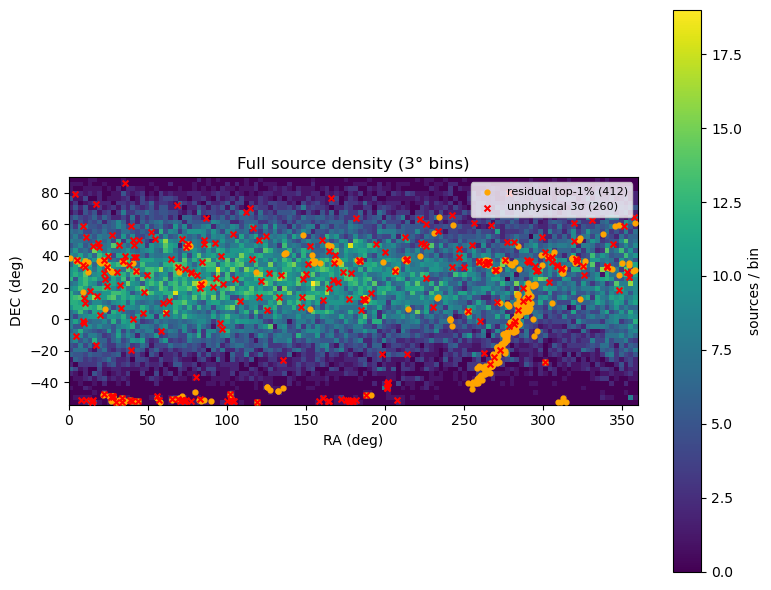


Fit-quality roll-up:


,band,n_sources,n_resid_top1,n_unphysical_3sig,max_bin_count,n_resid_and_unphysical
0,Full,27777,412,260,19,53
1,Blue,52174,647,262,43,126
2,Green,29280,397,64,22,41
3,Red,12583,203,29,14,18


In [11]:
import matplotlib.pyplot as plt

# Full-band 1° density map + flagged overlays; roll-up for all bands
primary_band = "Full" if "Full" in lst_merged else COLOR_BANDS[0]
df_full = lst_merged[primary_band]
H, ra_edges, dec_edges = sky_density_histogram(df_full, bin_deg=DENSITY_BIN_DEG)
top_bins = densest_bins(H, ra_edges, dec_edges, n=10)
print(f"Densest {DENSITY_BIN_DEG:g}° bins ({primary_band}):")
display(top_bins)

if H.size:
    fig, ax = plt.subplots(figsize=(8, 6))
    # H is (n_ra, n_dec); pcolormesh expects X,Y as edges
    mesh = ax.pcolormesh(ra_edges, dec_edges, H.T, shading="auto", cmap="viridis")
    fig.colorbar(mesh, ax=ax, label="sources / bin")
    qa = fit_qa.get(primary_band, {})
    high = qa.get("high_residual", pd.Series(False, index=df_full.index))
    unphys = qa.get("unphysical_flux", pd.Series(False, index=df_full.index))
    if high.any():
        ax.scatter(
            df_full.loc[high, "RA"],
            df_full.loc[high, "DEC"],
            s=12,
            c="orange",
            marker="o",
            label=f"residual top-1% ({int(high.sum())})",
            zorder=3,
        )
    if unphys.any():
        ax.scatter(
            df_full.loc[unphys, "RA"],
            df_full.loc[unphys, "DEC"],
            s=18,
            c="red",
            marker="x",
            label=f"unphysical 3σ ({int(unphys.sum())})",
            zorder=4,
        )
    ax.set_xlabel("RA (deg)")
    ax.set_ylabel("DEC (deg)")
    ax.set_title(f"{primary_band} source density ({DENSITY_BIN_DEG:g}° bins)")
    ax.set_aspect("equal", adjustable="box")
    ax.legend(loc="best", fontsize=8)
    fig.tight_layout()
    plt.show()
else:
    print(f"No finite RA/DEC for density map ({primary_band}).")

# Roll-up summary across bands
rows = []
for band in COLOR_BANDS:
    df = lst_merged[band]
    qa = fit_qa.get(band, {})
    H_b, _, _ = sky_density_histogram(df, bin_deg=DENSITY_BIN_DEG)
    max_bin = int(H_b.max()) if H_b.size else 0
    high = qa.get("high_residual", pd.Series(False, index=df.index))
    unphys = qa.get("unphysical_flux", pd.Series(False, index=df.index))
    rows.append(
        {
            "band": band,
            "n_sources": int(len(df)),
            "n_resid_top1": int(qa.get("n_resid_top1", high.sum())),
            "n_unphysical_3sig": int(qa.get("n_unphysical_3sig", unphys.sum())),
            "max_bin_count": max_bin,
            "n_resid_and_unphysical": int((high & unphys).sum()),
        }
    )

fit_qa_summary = pd.DataFrame(rows)
print("\nFit-quality roll-up:")
display(fit_qa_summary)


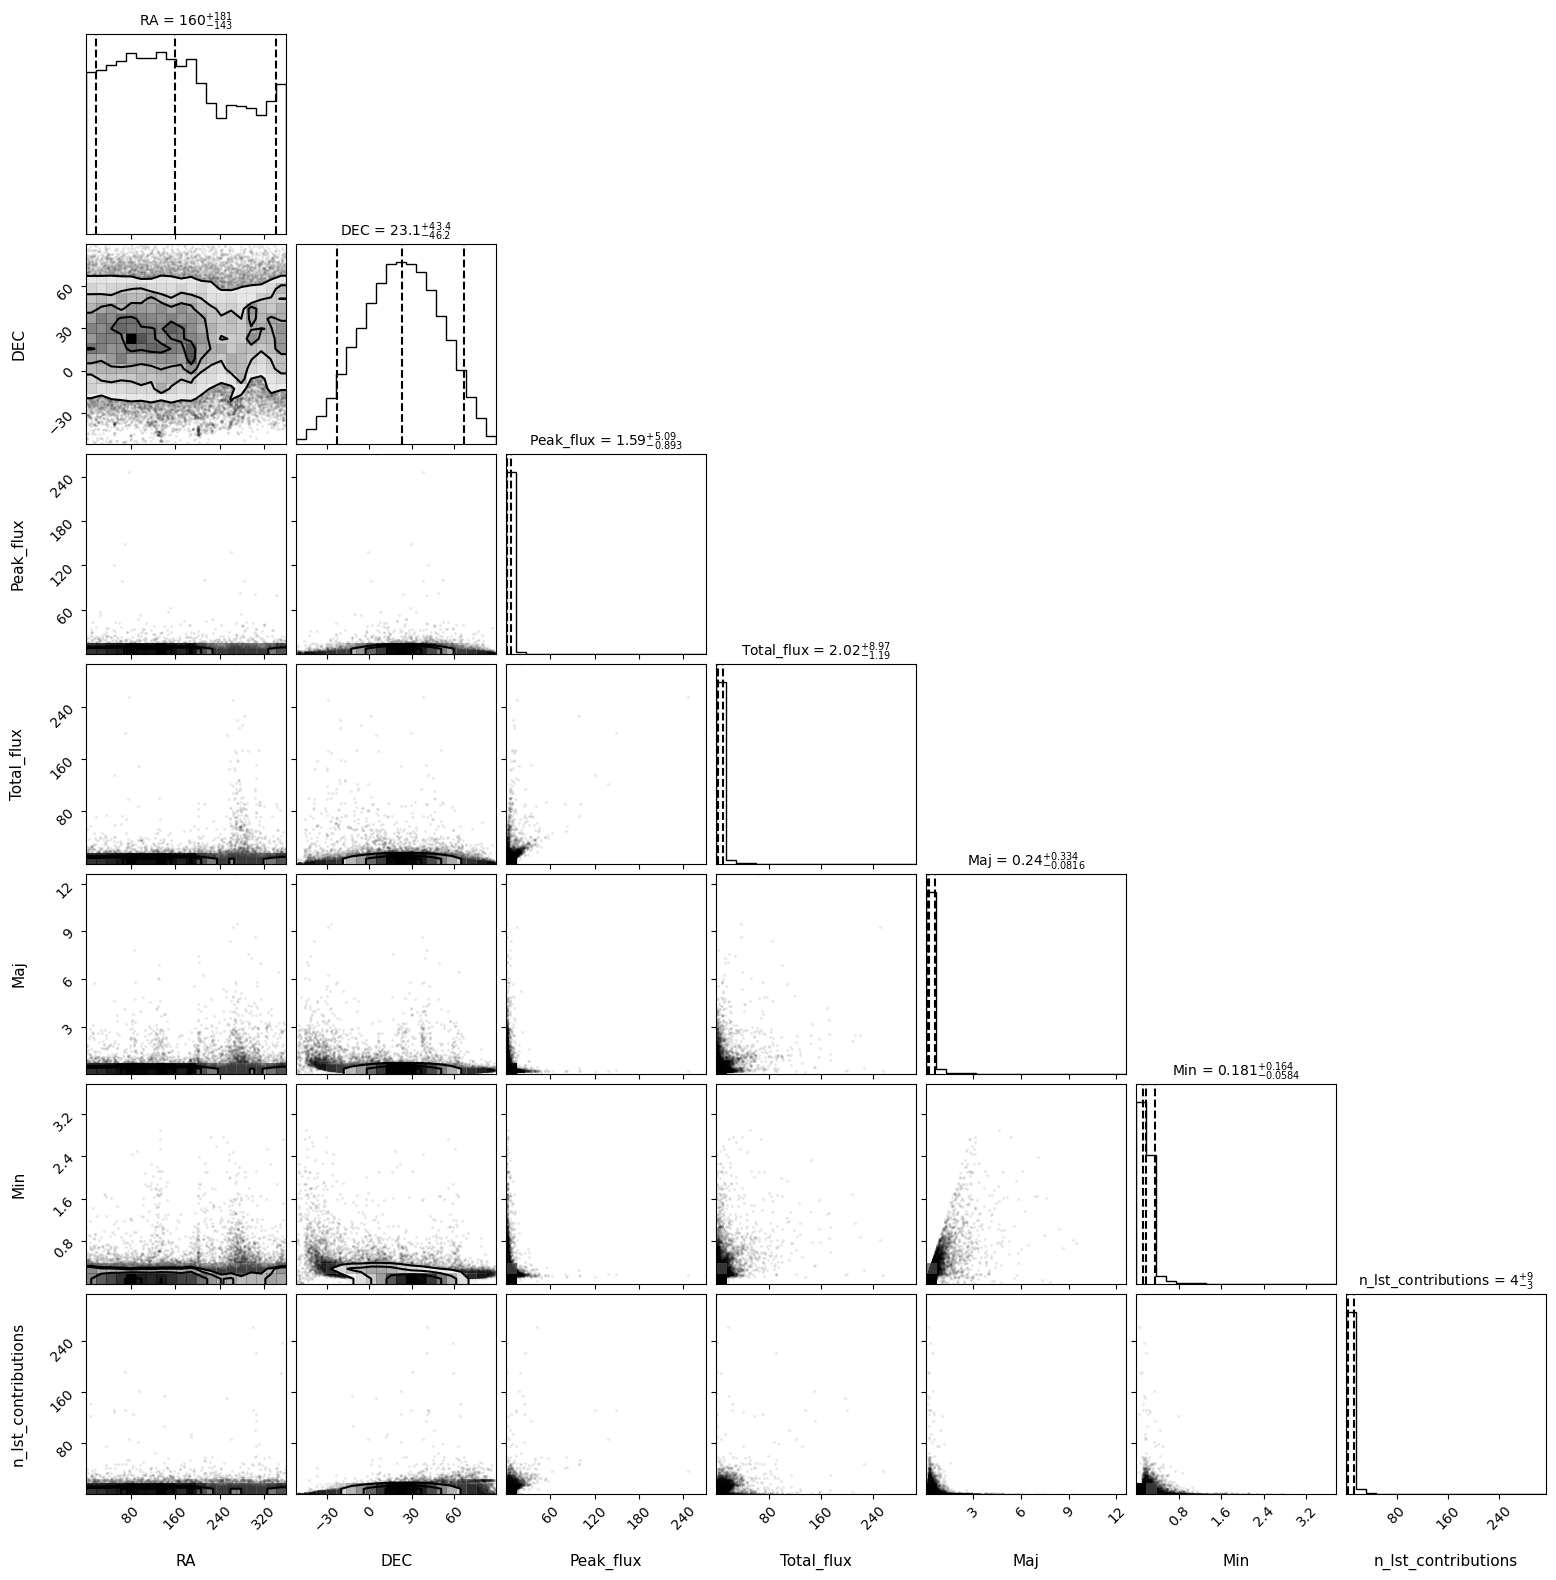

In [12]:
import corner
import matplotlib.pyplot as plt

cols = ["RA", "DEC", "Peak_flux", "Total_flux", "Maj", "Min", "n_lst_contributions"]

# drop NaNs; corner needs a clean numeric array
data = metacatalog[cols].dropna().to_numpy()

fig = corner.corner(
    data,
    labels=cols,
    quantiles=[0.05, 0.5, 0.95],
    show_titles=True,
    title_fmt=".3g",
    title_kwargs={"fontsize": 10},
    label_kwargs={"fontsize": 11},
)

# Save before show — Cursor/VS Code often cannot "download" inline plot images.
#OUT_PNG = OUTPUT_DIR / "metacatalog_corner.png"
#fig.savefig(OUT_PNG, dpi=150, bbox_inches="tight")
#print(f"Wrote {OUT_PNG}")
plt.show()


## Spectral index distribution

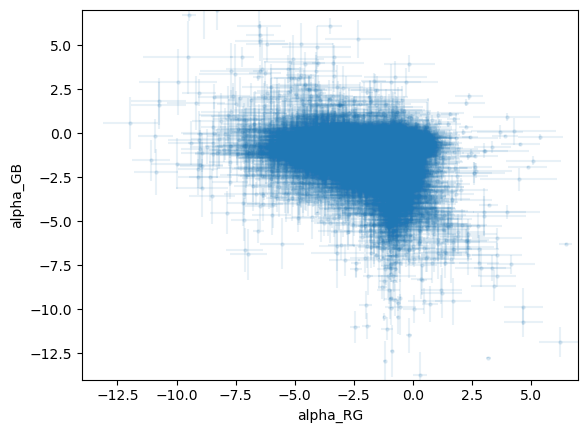

In [13]:
cols = ['meta_id', 'alpha_RG', 'E_alpha_RG', 'alpha_GB', 'E_alpha_GB']
data = metacatalog[cols].dropna(how='any')
ax = data.plot(x='alpha_RG', y='alpha_GB', xerr='E_alpha_RG', yerr='E_alpha_GB', marker='.', kind='scatter',
               alpha=0.1, xlim=[-14,7], ylim=[-14,7])
OUT_PNG = OUTPUT_DIR / "metacatalog_alpha.png"
ax.figure.savefig(OUT_PNG, dpi=150, bbox_inches="tight")

In [14]:
meta_ids = data[(data['alpha_RG']>1) & (data['alpha_GB']<-2)]['meta_id']

In [15]:
metacatalog.set_index('meta_id').loc[meta_ids].reset_index()

,meta_id,origin_band,bands_present,RA,DEC,Peak_flux,Total_flux,Maj,Min,PA,...,n_assoc_Red,BMAJ_full,source_file_Full,source_file_Blue,source_file_Green,source_file_Red,alpha_RG,E_alpha_RG,alpha_GB,E_alpha_GB
0,8,Full,"Full,Blue,Green,Red",341.452704,39.687773,79.947693,91.347820,0.245133,0.177805,57.190927,...,1,0.230273,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...,6.472693,0.258180,-6.313501,0.062575
1,24,Full,"Full,Blue,Green,Red",168.664354,40.624671,41.299576,31.895302,0.192618,0.146968,44.193348,...,1,0.226146,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...,3.211803,0.415909,-4.083858,0.052710
2,45,Full,"Full,Blue,Green,Red",85.653919,49.853519,34.252402,21.897251,0.179554,0.132810,32.736624,...,1,0.221042,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...,1.026635,0.151960,-3.258394,0.064043
3,836,Full,"Full,Blue,Green,Red",63.175721,23.089337,10.762269,9.020034,0.203343,0.160197,49.528201,...,1,0.226294,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...,1.057554,0.360927,-6.292548,0.950583
4,1585,Full,"Full,Blue,Green,Red",301.401124,44.496432,8.114179,8.419745,0.234691,0.173642,28.591967,...,1,0.235147,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...,2.577269,0.772675,-2.290641,0.662327
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,44204,Blue,"Blue,Green,Red",255.512382,12.878748,0.795636,6.397222,0.584245,0.309100,5.477686,...,1,NaN,NaN,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...,1.517206,0.973479,-4.885949,0.873641
76,45528,Blue,"Blue,Green,Red",99.724582,7.524097,0.763154,1.498575,0.255976,0.172107,173.431127,...,1,NaN,NaN,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...,2.875991,1.072618,-7.634539,1.084388
77,45765,Blue,"Blue,Green,Red",224.946411,18.865971,0.757485,1.367828,0.219445,0.164477,177.212454,...,1,NaN,NaN,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...,1.084231,1.015619,-6.798481,1.479038
78,46985,Blue,"Blue,Green,Red",188.261267,-1.991372,0.728224,1.168441,0.213488,0.192701,77.419012,...,1,NaN,NaN,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...,1.637241,0.893428,-7.166479,1.362442
